In [75]:
import argparse

def str_to_bool(value):
    """Convert argument string to boolean."""
    if isinstance(value, bool):
        return value
    if value.lower() in ('true', '1', 'yes', 'y'):
        return True
    elif value.lower() in ('false', '0', 'no', 'n'):
        return False
    else:
        raise argparse.ArgumentTypeError("Boolean value expected (true/false or 1/0).")
        
def int_or_str(val):
    try:
        return int(val)
    except ValueError:
        return val

parser = argparse.ArgumentParser()
parser.add_argument("--index", type=int_or_str, required=True, help="Filename index")
parser.add_argument("--retrain", type=str_to_bool, required = False, default = True)
parser.add_argument("--separation_subset", type=str_to_bool, required = False, default = False)

parser.add_argument("--n_batches", type=int, required=True)


parser.add_argument("--max_epochs", type=int, required=True)
parser.add_argument("--per_condition_reconstruction_loss", type=str_to_bool, required=True)

parser.add_argument("--vae_scaling_KL", type=float, required=True)
parser.add_argument("--n_cat_discriminator_train", type=int, required=True)
parser.add_argument("--n_pert_discriminator_train", type = int, required = True)
parser.add_argument("--cat_spectral_norm", type=str_to_bool, required=True)
parser.add_argument("--pert_spectral_norm", type = str_to_bool, required = True)

parser.add_argument("--n_adversarial_start", type = int, required = True)

parser.add_argument("--cat_dropout", type=float, required=True)
parser.add_argument("--pert_dropout", type=float, required=True)

parser.add_argument("--generator_dropout_rate", type=float, required=True)
parser.add_argument("--n_layers_vae", type=int, required=True)

parser.add_argument("--main_max_lr", type=float, required=True)
parser.add_argument("--gen_max_lr", type=float, required=True)
parser.add_argument("--cat_max_lr", type=float, required=True)
parser.add_argument("--pert_max_lr", type=float, required=True)


parser.add_argument("--cat_max_penalty_weight", type=float, required=True)
parser.add_argument("--cat_b_adv", type=float, required=True)
parser.add_argument("--pert_max_penalty_weight", type=float, required=True)
parser.add_argument("--pert_b_adv", type=float, required=True)


parser.add_argument("--cat_bias_pert_scaler", type=float, required=True)
parser.add_argument("--cat_pert_pert_label", type=str_to_bool, default=False)
parser.add_argument("--cat_bias_lambda_L2", type=float, required=True)

parser.add_argument("--spectral_loss_factor", type=float, required=True)
parser.add_argument("--uniform_lambda_L2", type=float, required=True)


########################################################################
args = parser.parse_args()
fn = str(args.index)

retrain = args.retrain

separation_subset = args.separation_subset 

max_epochs = args.max_epochs
per_condition_reconstruction_loss = args.per_condition_reconstruction_loss
n_batches = args.n_batches

vae_scaling_KL = args.vae_scaling_KL
n_cat_discriminator_train = args.n_cat_discriminator_train
n_pert_discriminator_train = args.n_pert_discriminator_train
n_adversarial_start = args.n_adversarial_start
pert_spectral_norm = args.pert_spectral_norm
cat_spectral_norm = args.cat_spectral_norm

main_max_lr = args.main_max_lr
gen_max_lr = args.gen_max_lr
cat_max_lr = args.cat_max_lr
pert_max_lr = args.pert_max_lr

cat_dropout = args.cat_dropout
pert_dropout = args.pert_dropout

generator_dropout_rate = args.generator_dropout_rate
n_layers_vae = args.n_layers_vae


cat_max_penalty_weight = args.cat_max_penalty_weight
cat_b_adv = args.cat_b_adv
pert_max_penalty_weight = args.pert_max_penalty_weight
pert_b_adv = args.pert_b_adv

cat_bias_pert_scaler = args.cat_bias_pert_scaler
cat_pert_pert_label = args.cat_pert_pert_label
cat_bias_lambda_L2 = args.cat_bias_lambda_L2 

spectral_loss_factor = args.spectral_loss_factor
uniform_lambda_L2 = args.uniform_lambda_L2


#python test_run.py --index 7 --retrain false --separation_subset false --max_epochs 600 --per_condition_reconstruction_loss true --n_batches 10 --vae_scaling_KL 5e-3 --n_cat_discriminator_train 10 --n_pert_discriminator_train 10 --cat_dropout 0.1 --pert_dropout 0.3 --n_adversarial_start 200 --main_max_lr 2e-3 --gen_max_lr 5e-4 --cat_max_lr 1e-3 --pert_max_lr 1e-3 --cat_max_penalty_weight 11 --cat_b_adv 2.5 --pert_max_penalty_weight 10 --pert_b_adv 2.75 --generator_dropout_rate 0.7 --n_layers_vae 3 --cat_bias_pert_scaler 100 --cat_pert_pert_label false --cat_bias_lambda_L2 1e-4 --spectral_loss_factor 0 --uniform_lambda_L2 0 --cat_spectral_norm true --pert_spectral_norm true


In [1]:
index = 7
fn = str(index)
retrain = True
separation_subset = True

max_epochs = 600
per_condition_reconstruction_loss = False
n_batches = 10 # 20 is like kang

n_cat_discriminator_train = 5
n_pert_discriminator_train = 5
cat_dropout = 0.1
pert_dropout = 0.1
n_adversarial_start = 200
main_max_lr = 2e-3
gen_max_lr = 5e-4 #2.75e-4
cat_max_lr = 1e-3
pert_max_lr = 1e-3

# adversarial params
cat_b_adv = 2.5 # 2 in kang
cat_max_penalty_weight = 10
pert_b_adv = 2.75 #2 
pert_max_penalty_weight = 10 #15


generator_dropout_rate = 0.7

n_layers_vae = 3 # 2 in Kang
cat_bias_pert_scaler = 100
cat_pert_pert_label = False
cat_bias_lambda_L2 = 1e-4
spectral_loss_factor = 0
uniform_lambda_L2 = 0

batch_scaler_mem = 1

vae_scaling_KL = 1e-3

# Contrastive loss parameters
# contrastive_loss_scaler = [1, 0.2]
# contrastive_loss_type = ["sc_actual", "sc_predicted"]
# contrastive_percentile = 0.3
# contrastive_triplet_margin_frac = 0.1

# Spectral norm flags
cat_spectral_norm = True
pert_spectral_norm = True


In [2]:
import os
import time
import math
import joblib

from tqdm import tqdm

import pandas as pd
import numpy as np
import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS import preprocess as pp 
from scLEMBAS.model.train import TrainSC
from scLEMBAS.model.scl import SignalingModel
from scLEMBAS import latent_separation as ls

import sys
sys.path.insert(1, '../.')
import McCauley_utils as Mu

/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm_joblib/__init__.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/us

In [3]:
n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

seed = 888
mod_seed = 888
data_path = '/home/hmbaghda/orcd/pool/scLEMBAS/analysis'
author = 'McCauley'

device = "cuda" if torch.cuda.is_available() else "cpu"


In [4]:
adata = sc.read_h5ad(os.path.join(data_path, 'processed', author + '_normalized_counts.h5ad'))
adata = adata[:, adata.var['highly_variable']].copy() # filter for HVGs

if separation_subset:
    sn_ppis = pd.read_csv(os.path.join(data_path, 'trash', author + 'sepsubset_sn_ppis.csv'), 
                     index_col = 0)
    tf_adata = io.read_tfad(os.path.join(data_path, 'trash', author + 'sepsubset_consensus_tf_activity.h5ad'))
    adata = adata[tf_adata.obs_names, :].copy()
else:
    sn_ppis = pd.read_csv(os.path.join(data_path, 'processed', author + '_sn_ppis.csv'), 
                     index_col = 0)
    tf_adata = io.read_tfad(os.path.join(data_path, 'processed', author + '_consensus_tf_activity.h5ad'))


source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

cat_col = 'cell_type'
pert_col = 'ligand'
ctrl_pert = 'CTRL'



expr = adata.to_df().copy()

# basic formatting checks
if not np.all(tf_adata.var_names == sorted(tf_adata.var_names)):
    raise ValueError('Ensure TF adata features are sorted on input')
    
if not np.all(adata.obs_names == tf_adata.obs_names):
    raise ValueError('Ensure gene expression and TF activity sample features are orderd the same')
    
if len(set(tf_adata.obs[pert_col])) != len(tf_adata.obs[pert_col].cat.categories):
    raise ValueError('Make sure only present perturbations are in the categorical columns')
    
if len(set(tf_adata.obs[cat_col])) != len(tf_adata.obs[cat_col].cat.categories):
    raise ValueError('Make sure only present cell lines are in the categorical columns')


# Train/test split:

In [22]:
split = Mu.split_data(
    tf_adata = tf_adata, 
    train_frac = 0.8 if not separation_subset else 0.75,
    min_cat_frac = 1, 
    min_pert_frac = 0.6 if not separation_subset else 0.5, 
    deviation_thresh = 0.025, 
    max_attempts = 1000, 
    exclude_pert_control = True, 
    pert_col = pert_col,
    ctrl_pert = ctrl_pert,
    seed = seed 
)


In [23]:
assert len({cond.split('^')[1] for cond in split['test_conds']}.difference({cond.split('^')[1] for cond in split['train_conds']})) == 0, 'Missing perturbations in split'

test_mask = tf_adata.obs.condition.isin(split['test_conds'])
train_mask = tf_adata.obs.condition.isin(split['train_conds'])

n_train_cells = np.sum(train_mask)
n_test_cells = np.sum(test_mask)

test_counts = tf_adata.obs.loc[test_mask, 'condition'].value_counts()
test_counts[test_counts != 0]

condition
Basal^IFNA2     3179
Basal^BMP4      2294
Club^IL13        187
Goblet^IFNA2      57
Name: count, dtype: int64

In [24]:
train_counts = tf_adata.obs.loc[train_mask, 'condition'].value_counts()
train_counts[train_counts != 0]

condition
Basal^TGFB1    5448
Basal^CTRL     2597
Club^CTRL      2367
Basal^IFNG     2206
Basal^IL13     1114
Club^BMP4       858
Goblet^IL13     726
Club^IFNA2      525
Club^TGFB1       96
Club^IFNG        43
Goblet^CTRL      40
Name: count, dtype: int64

# Hyperparameters

In [59]:
def generate_lr_params(n_epochs, 
                       max_lr, 
                       lr_scaling_factor=10, 
                       lr_decay=0.75,
                       n_restarts=4,
#                        n_cat_discriminator_train=5,
#                        n_pert_discriminator_train=5,
                       n_adversarial_start=0,
                       role='scl'):
    """
    Generate LR scheduler params for WarmupCosineAnnealingWarmRestarts
    that ensures discriminator and generator follow the same curve in real (epoch) time.

    For 'generator', it updates when either discriminator is active.

    Returns:
        Dict of scheduler parameters
    """

    total_active_epochs = n_epochs
    n_steps = n_epochs  # default for SCL

    if role in ['generator', 'cat_discriminator', 'pert_discriminator']:
        if n_adversarial_start >= n_epochs: # won't be used anyways
            n_adversarial_start = 0
        total_active_epochs = n_epochs - n_adversarial_start
        n_steps = total_active_epochs // 1

#    DEPRECATED: this was necessary when generator trained every n_discriminator_train epochs
#                rather than discriminator training n_discriminator_train times every epoch
#     elif role in 'generator':
#         # Generator steps on any epoch divisible by either cat or pert discriminator schedule
#         effective_epochs = range(n_adversarial_start, n_epochs)
#         n_steps = sum(
#             (e % n_cat_discriminator_train == 0) or (e % n_pert_discriminator_train == 0)
#             for e in effective_epochs
#         )

    T_0 = max(1, n_steps // n_restarts)
    warmup_epochs = max(1, n_steps // 10)

    if warmup_epochs >= T_0:
        warmup_epochs = 0

    return {
        'max_epochs': n_epochs,
        'maximum_learning_rate': max_lr,
        'minimum_learning_rate': max_lr / lr_scaling_factor,
        'lr_restart_epoch': T_0,
        'n_optimizer_resets': 0,
        'lr_decay': lr_decay,
        'lr_restart_factor': 1,
        'warmup_epochs': warmup_epochs
    }


In [60]:
projection_amplitude_in = 10
projection_amplitude_out = 1

bionet_params = {'target_steps': 100, 
                 'max_steps': 120, 
                 'exp_factor': 50, 
                 'tolerance': 1e-5, 
                 'leak': 1e-2}

spectral_radius_params = {'n_probes_spectral': 5, 
                          'power_steps_spectral': 5, 
                          'subset_n_spectral': 5, 
                         'track_spectral_radius': True}
target_spectral_radius = 0.9

noise_params = {
    'network_noise_scale': 0.01, 
    'min_network_noise': 0.0025, #0.0015, #0.0025, 
    'gradient_noise_scale': 1e-9, 
    'include_gradient_noise_vae': True, 
    'include_gradient_noise_embedding': True, 
    'constant_gradient_noise': True
    
}

In [61]:
loss_scaler = 100
prediction_loss_fn = torch.nn.MSELoss(reduction='mean')

batch_params = {
    'train_batch_size': int(np.round(n_train_cells/n_batches)), 
    'test_batch_size': int(np.round(n_test_cells/n_batches)), 
    'validation_batch_size': np.nan
}


lr_scaling_factor = 10
lr_decay = 0.9
n_restarts = 4
lr_params = generate_lr_params(n_epochs = max_epochs, 
                               max_lr = main_max_lr, 
                               lr_scaling_factor = lr_scaling_factor, 
                               lr_decay = lr_decay,
                               n_restarts = n_restarts,
                               n_adversarial_start = np.nan, 
#                                n_cat_discriminator_train = np.nan, 
#                                n_pert_discriminator_train = np.nan,
                               role = 'scl')


In [62]:
bionet_params['cat_max_norm'] = 100
regularization_params = {
    'input_lambda_L2': 0, # irrelevant because setting the requires grad to False
    
    'bn_weights_lambda_L2': 1e-7,
    'moa_lambda_L1': 1e2,
    'uniform_lambda_L2': uniform_lambda_L2, #0, #1e-7, 
    'uniform_min': -1/projection_amplitude_out,
    'uniform_max': 1/projection_amplitude_out,
    'adj_scaling_KL': 0,  # using uniform/bn_weights already
    'adj_prior_mu': 0, # irrelevant because adj_scaling_KL is 0
    'adj_prior_sigma': 0.2, # irrelevant because adj_scaling_KL is 0
    
    'output_weights_lambda_L2': 1e-7,
    'output_bias_lambda_L2': 1e-7,
    
    'spectral_loss_factor': spectral_loss_factor,
    
    
    'global_bias_lambda_L2': 0, # using KL divergence instead
    'global_bias_lambda_L1': 0, # using KL divergence instead
    'cat_bias_lambda_L2': cat_bias_lambda_L2, # 1e-4, # allow for generalization (not collapsing on perturbation)
    'cat_bias_lambda_L1': 0, # using cat max norm
}



contrastive_loss_params = {
    'methods': [], 
    'lambda_scalers': [], 
    'understimate_only': np.nan, # only for _bulk_actual
    'min_percentile': np.nan, # only for _sc
    'triplet_margin_frac': np.nan, # for sc only
}


cat_pert_params = {
    'regularization_scaler': cat_bias_pert_scaler, 
    'method': 'orthogonality', 
    'per_label': cat_pert_pert_label, 
    'include_adjacency': False, 
    'temperature': 0.1
                      }



In [63]:
training_params = {
    **lr_params, 
    **batch_params, 
    **regularization_params, 
    **spectral_radius_params,
    **noise_params
}

training_params['prediction_loss_fn_scaler'] = loss_scaler

## VAE:

In [64]:
# building
n_nodes = len(set(sn_ppis[source_label].tolist() + sn_ppis[target_label].tolist()))
vae_n_hidden_nodes = list(np.round(np.linspace(adata.shape[1], n_nodes, n_layers_vae + 2)).astype(int)[1:-1])

# generator_dropout_rate = 0.7
vae_mod_params = {
    'vae_batch_momentum': 0.01, 
    'vae_layer_norm': False, 
    'vae_dropout_rate': generator_dropout_rate,
    'vae_activation_fn': nn.LeakyReLU,
    'vae_n_hidden_nodes': vae_n_hidden_nodes, 
    'vae_var_min': 1e-4

} 
bionet_params = {**bionet_params, **vae_mod_params}

# training
vae_params = {
    'prior_mu': 0, 
    'prior_sigma': 1,
    'scaling_KL': vae_scaling_KL, #1e-2, 
    'lambda_l2': 1e-5, 
    'optimizer': torch.optim.Adam
}

 
n_restarts_adversarial = 4
vae_lr_params = generate_lr_params(n_epochs = max_epochs,
                                   max_lr = gen_max_lr, #max_lr,
                                   lr_scaling_factor = lr_scaling_factor, 
                                   lr_decay = lr_decay,
                                   n_restarts = n_restarts_adversarial,
                                   n_adversarial_start = n_adversarial_start,
#                                n_cat_discriminator_train = n_cat_discriminator_train, 
#                                n_pert_discriminator_train = n_pert_discriminator_train,
                                   role = 'generator')
vae_params = {**vae_params, **vae_lr_params}
del vae_params['max_epochs']


## Discriminator

In [65]:
discriminator_params = {
    'batch_momentum': None,
    'layer_norm': False,
    'spectral_norm': np.nan, #False,
    'dropout_rate': np.nan,
    'activation_fn': nn.LeakyReLU,
    'n_hidden_nodes': np.nan,
    'lr_restart_factor': 1,
    'optimizer': torch.optim.Adam,
    'discriminator_lambda_L2': 1e-3,
    'discriminator_penalty_weight': np.nan, 
    'bionet_activation': False,
    'smooth_labels': True, 
    'epsilon_smooth': np.nan
}

In [66]:
cat_n_layers_disc = 3
cat_disc_n_hidden_nodes = list(np.round(np.linspace(n_nodes, 
                                                    tf_adata.obs[cat_col].nunique(),
                                                    cat_n_layers_disc + 2)).astype(int)[1:-1])
cat_discriminator_params = discriminator_params.copy()
cat_discriminator_params['n_hidden_nodes'] = cat_disc_n_hidden_nodes
cat_discriminator_params['dropout_rate'] = cat_dropout

cat_discriminator_params['spectral_norm'] = cat_spectral_norm
if cat_spectral_norm:
    cat_discriminator_params['discriminator_lambda_L2'] = 0


pert_n_layers_disc = 3
pert_disc_n_hidden_nodes = list(np.round(np.linspace(n_nodes, 
                                                    tf_adata.obs[pert_col].nunique(),
                                                    pert_n_layers_disc + 2)).astype(int)[1:-1])

# add 3 additional "starting" layers since classifying perturbation is difficult
pert_disc_n_hidden_nodes = [pert_disc_n_hidden_nodes[0]]*3 + pert_disc_n_hidden_nodes

pert_discriminator_params = discriminator_params.copy()
pert_discriminator_params['n_hidden_nodes'] = pert_disc_n_hidden_nodes
pert_discriminator_params['dropout_rate'] = pert_dropout

pert_discriminator_params['spectral_norm'] = pert_spectral_norm
if pert_spectral_norm:
    pert_discriminator_params['discriminator_lambda_L2'] = 0

cat_discriminator_params['epsilon_smooth'] = min(0.1, 1/tf_adata.obs[cat_col].nunique())
pert_discriminator_params['epsilon_smooth'] = min(0.1, 1/tf_adata.obs[pert_col].nunique())

Adversarial weights:

In [67]:
# adverserial penalty curve


if n_adversarial_start < max_epochs:
    cat_discriminator_params['discriminator_penalty_weight'] = pp.discriminator_weight_curve(
        n_epochs = max_epochs - n_adversarial_start,
        min_penalty_weight = 0.001,
        max_penalty_weight = cat_max_penalty_weight,
        a = 1,
        b = cat_b_adv, 
        curve_type = 'power')

#     n_pert_train = int(max_epochs/2)
#     pert_discriminator_penalty_weight = [0] * n_pert_train
#     pert_discriminator_penalty_weight += pp.discriminator_weight_curve(
#         n_epochs = max_epochs - n_pert_train - n_adversarial_start,
#         min_penalty_weight = 1e-5,
#         max_penalty_weight = pert_max_penalty_weight,
#         a = 1,
#         b = pert_b_adv, 
#         curve_type = 'power')

    pert_discriminator_params['discriminator_penalty_weight'] = pp.discriminator_weight_curve(
        n_epochs = max_epochs - n_adversarial_start,
        min_penalty_weight = 0.001,
        max_penalty_weight = pert_max_penalty_weight,
        a = 1,
        b = pert_b_adv, 
        curve_type = 'power')
else:
    cat_discriminator_params['discriminator_penalty_weight'] = [0]*max_epochs
    pert_discriminator_params['discriminator_penalty_weight'] = [0]*max_epochs



In [68]:
# discriminator LRs

# categorical
discriminator_lr_params = generate_lr_params(
    n_epochs = max_epochs,
    max_lr = cat_max_lr,
    lr_scaling_factor = lr_scaling_factor, 
    lr_decay = lr_decay,
    n_restarts = n_restarts_adversarial,
    n_adversarial_start = n_adversarial_start, 
#     n_pert_discriminator_train = np.nan,
#     n_cat_discriminator_train = n_cat_discriminator_train,
    role = 'cat_discriminator')
del discriminator_lr_params['max_epochs']

cat_discriminator_params = {**cat_discriminator_params, **discriminator_lr_params}

# perturbation
discriminator_lr_params = generate_lr_params(
    n_epochs = max_epochs,
    max_lr = pert_max_lr,
    lr_scaling_factor = lr_scaling_factor, 
    lr_decay = lr_decay,
    n_restarts = n_restarts_adversarial,
    n_adversarial_start = n_adversarial_start, 
#     n_pert_discriminator_train = n_pert_discriminator_train,
#     n_cat_discriminator_train = np.nan,
    role = 'pert_discriminator')
del discriminator_lr_params['max_epochs']

pert_discriminator_params = {**pert_discriminator_params, **discriminator_lr_params}

Visualize hyperparameters:

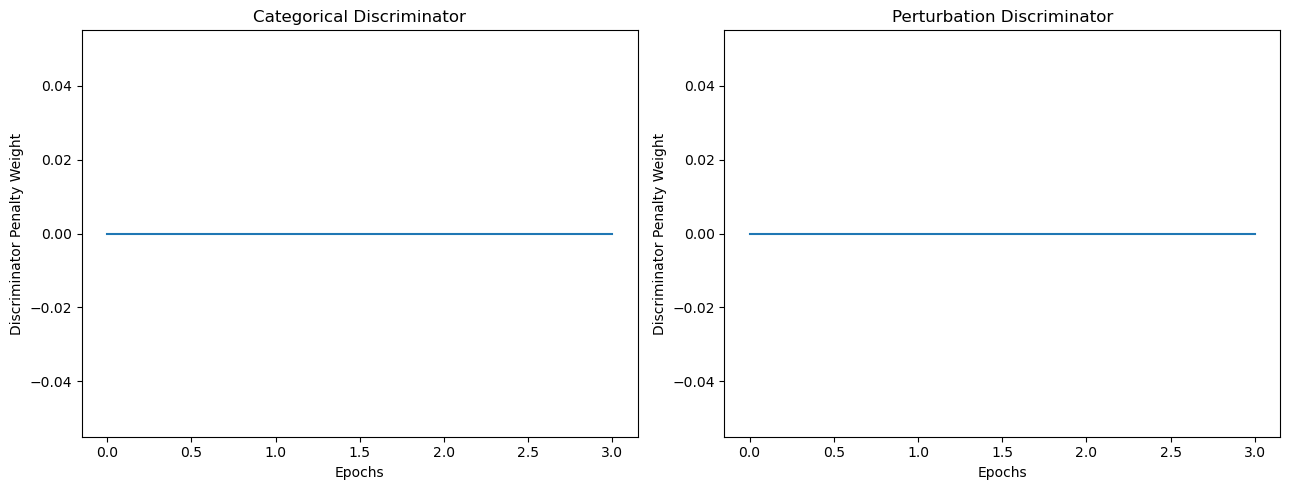

In [69]:
fig, ax = plt.subplots(ncols = 2, figsize = (13,5))
sns.lineplot(cat_discriminator_params['discriminator_penalty_weight'], ax = ax[0])
ax[0].set_title('Categorical Discriminator')

sns.lineplot(pert_discriminator_params['discriminator_penalty_weight'], ax = ax[1])
ax[1].set_title('Perturbation Discriminator')

for i in range(2):
    ax[i].set_xlabel('Epochs')
    ax[i].set_ylabel('Discriminator Penalty Weight')
    
fig.tight_layout();

# Build model and trainer

In [70]:
# input stimulation
X_in = pd.get_dummies(tf_adata.obs[pert_col]).astype(int)
X_in.drop(columns = ctrl_pert, inplace = True) # all 0s

In [71]:
mod = SignalingModel(
    net = sn_ppis,
    X_in = X_in,
    y_out = tf_adata.to_df().copy(), 
    expr = expr, 
    covariates = tf_adata.obs.copy(),
    categorical_covariate_keys = [cat_col],
    projection_amplitude_in = projection_amplitude_in, 
    projection_amplitude_out = projection_amplitude_out,
    weight_label = weight_label, source_label = source_label, target_label = target_label,
    bionet_params = bionet_params, 
    dtype = torch.float32, device = device, seed = mod_seed)

mod.input_layer.weights.requires_grad = False # don't learn scaling factors for the ligand input concentrations
mod.signaling_network.prescale_weights(target_radius = target_spectral_radius) # spectral radius


In [134]:
trainer = TrainSC(
    mod = mod,
    prediction_optimizer = torch.optim.Adam,
    prediction_loss_fn = prediction_loss_fn, 
    per_condition_loss = per_condition_reconstruction_loss,
    n_adversarial_start = n_adversarial_start, 
    n_cat_discriminator_train = n_cat_discriminator_train,
    n_pert_discriminator_train = n_pert_discriminator_train,
    gradient_ascent = True,
    cat_discriminator_params = cat_discriminator_params,
    pert_discriminator_params = pert_discriminator_params,
    vae_params = vae_params,
    hyper_params = training_params,
    contrastive_loss_params = contrastive_loss_params,
    cat_pert_params = cat_pert_params,
    train_split = {'train': split['train_barcodes'], 'test': split['test_barcodes'], 'validation': None}, 
    train_seed = mod_seed, 
    n_track_test = 20,
    n_track_validation = None, 
    n_eval_cells = np.nan, 
    n_eval_bootstrap = np.nan
    )
    
if retrain or not os.path.isfile(os.path.join(data_path, 'trash', fn + author +  '_trainer.pickle')):
    mod = trainer.train_model(verbose = False)
    io.write_pickled_object(trainer, os.path.join(data_path, 'trash', fn + author +  '_trainer.pickle'))

In [6]:
import papermill as pm
from nbconvert import HTMLExporter
from traitlets.config import Config
import nbformat
import os

# ---------- Parameters ----------
input_notebook = 'test_visualize.ipynb'  # Template notebook
output_notebook = os.path.join(data_path, 'trash', fn + '_' + author + '.ipynb')
output_html = os.path.join(data_path, 'trash', fn + '_' + author + '.html')

# ---------- Step 1: Execute notebook with Papermill ----------
pm.execute_notebook(
    input_path=input_notebook,
    output_path=output_notebook,
    parameters={"fn": fn, 'separation_subset': separation_subset},
    kernel_name='python3'
)

# ---------- Step 2: Load executed notebook ----------
with open(output_notebook, 'r', encoding='utf-8') as f:
    nb = nbformat.read(f, as_version=4)

# ---------- Step 3: Configure HTML exporter ----------
c = Config()
c.HTMLExporter.preprocessors = ['nbconvert.preprocessors.TagRemovePreprocessor']
c.TagRemovePreprocessor.remove_cell_tags = ('remove_cell',)
c.TagRemovePreprocessor.remove_input_tags = ('remove_input',)
c.TagRemovePreprocessor.remove_all_outputs_tags = ('remove_output',)
c.TagRemovePreprocessor.enabled = True

html_exporter = HTMLExporter(config=c, template_name='classic')
html_exporter.exclude_input = False  # Keep code cells visible (so they can be toggled)

# ---------- Step 4: Export notebook to HTML ----------
(body, resources) = html_exporter.from_notebook_node(nb)

# ---------- Step 5: Add toggleable JavaScript ----------
custom_js = """
<script>
document.addEventListener('DOMContentLoaded', function(){
    var cells = document.querySelectorAll('.cell.code_cell .input');
    cells.forEach(function(cell) {
        var button = document.createElement('button');
        button.textContent = 'Show Code';
        button.style.display = 'block';
        button.style.margin = '5px 0';
        button.style.padding = '2px 6px';
        button.style.fontSize = '12px';
        button.style.backgroundColor = '#f0f0f0';
        button.style.border = '1px solid #ccc';
        button.style.cursor = 'pointer';

        button.onclick = function() {
            if (cell.style.display === 'none' || cell.style.display === '') {
                cell.style.display = 'block';
                button.textContent = 'Hide Code';
            } else {
                cell.style.display = 'none';
                button.textContent = 'Show Code';
            }
        };

        cell.parentNode.insertBefore(button, cell);
        cell.style.display = 'none';  // Hide all code blocks by default
    });
});
</script>
"""

html_with_js = body.replace('</body>', custom_js + '</body>')

# ---------- Step 6: Save final HTML ----------
with open(output_html, 'w', encoding='utf-8') as f:
    f.write(html_with_js)

# ---------- Step 7: Optional cleanup ----------
os.remove(output_notebook)
